In [1]:
# Libraries and configurations
import sys
from pathlib import Path
import json

# PyTorch
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import models
from torchvision import transforms
from torchinfo import summary

# Visualization and analysis
import os
import seaborn as sns
import PIL
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm
import pandas as pd
from sklearn.metrics import confusion_matrix, classification_report
from sklearn.metrics import cohen_kappa_score

# Adds the project root to the path
project_root = Path.cwd().parent
sys.path.insert(0, str(project_root))

from config import (
    get_dataset_paths
)

from src.dataset import DataModuleParasite
from src import utils
from src import models
from src import trainer

seed = 42
torch.manual_seed(seed)
np.random.seed(seed)

### Eggs: Trained from Scratch

In [2]:
# Configuration for Eggs Dataset

CONFIG_EGG = {
    'dataset_name': 'eggs',
    'split': [1, 2, 3],
    'percentage': [1, 5, 25, 50, 75, 100],
    'num_classes': 9,
    'batch_size': 16,
    'num_workers': 4,
    'image_size': 200,
    'lr': 1e-4,
    'num_epochs': 100,
    'device': 'cuda' if torch.cuda.is_available() else 'cpu'
}

# Create dataloaders
dataset_name = CONFIG_EGG['dataset_name']
model_name = 'mobilenetv3_small_scratch'
type_model = 'mobilenetv3_small'
pre_trained = False
path = f"{type_model}/{model_name}/{dataset_name}"
config = CONFIG_EGG
dataloaders = {}

transforms_egg = transforms.Compose([
    transforms.Resize((config['image_size'], config['image_size'])),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

dataloaders = utils.create_dataloaders(config=config, transforms=transforms_egg)

model_scratch, _, _, _ = models.create_model(type_model=type_model, description_path=f"{path}/{model_name}_model_params_{dataset_name}.txt", config=config, pre_trained=pre_trained)

n_flops, n_params = utils.count_flops(model_scratch, input_size=(1, 3, config['image_size'], config['image_size']))
print(f"Model: {model_name} - Dataset: {dataset_name}")
print(f"FLOPs: {n_flops} FLOPs")
print(f"Parameters: {n_params} ")

Model: mobilenetv3_small_scratch - Dataset: eggs
FLOPs: 54161256.0 FLOPs
Parameters: 1527081.0 


In [3]:
# Training loop with pre-trained weights
historic_train = trainer.train_loop(config, dataloaders, path, dataset_name, model_name=model_name, type_model=type_model, pre_trained=pre_trained)

# Save training history
with open(f'{path}/{model_name}_historic_{config["dataset_name"]}.json', 'w') as f:
    json.dump(historic_train, f)
    

Early stopping at epoch 38 for split 1 and percentage 1%


Early stopping at epoch 33 for split 2 and percentage 1%


Early stopping at epoch 24 for split 3 and percentage 1%


Early stopping at epoch 25 for split 1 and percentage 5%


Early stopping at epoch 24 for split 2 and percentage 5%


...

Early stopping at epoch 63 for split 2 and percentage 75%


Early stopping at epoch 62 for split 3 and percentage 75%


Early stopping at epoch 40 for split 1 and percentage 100%


Early stopping at epoch 51 for split 2 and percentage 100%


Early stopping at epoch 78 for split 3 and percentage 100%


In [4]:
utils.loss_and_accuracy_split(config, path, model_name, show_plot=False)
utils.loss_and_accuracy_aggregate(config, path, model_name, show_plot=False)

results_test = utils.evaluate_test_set(config, path, model_name, dataloaders, type_model=type_model, pre_trained=pre_trained)  

# Save results to JSON
with open(f'{path}/{model_name}_test_results_{config["dataset_name"]}.json', 'w') as f:
    json.dump(results_test, f)

utils.calculate_and_save_reports(config, path, model_name)

Aggregated classification reports saved to mobilenetv3_small/mobilenetv3_small_scratch/eggs/mobilenetv3_small_scratch_aggregated_classification_report_eggs.txt


### Larvae: Trained from Scratch

In [5]:
# Configuration for Larvae Dataset
CONFIG_LARVAE = {
    'dataset_name': 'larvae',
    'split': [1,2,3],
    'percentage': [1, 5, 25, 50, 75, 100],
    'num_classes': 2,
    'batch_size': 16,
    'num_workers': 4,
    'image_size': 200,
    'lr': 1e-4,
    'num_epochs': 100,
    'device': 'cuda' if torch.cuda.is_available() else 'cpu'
}

# Create dataloaders
dataset_name = CONFIG_LARVAE['dataset_name']
model_name = 'mobilenetv3_small_scratch'
type_model = 'mobilenetv3_small'
pre_trained = False
path = f"{type_model}/{model_name}/{dataset_name}"
config = CONFIG_LARVAE
dataloaders = {}

transforms_larvae = transforms.Compose([
    transforms.Resize((config['image_size'], config['image_size'])),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

dataloaders = utils.create_dataloaders(config=config, transforms=transforms_larvae)

model_scratch, _, _, _ = models.create_model(type_model=type_model, description_path=f"{path}/{model_name}_model_params_{dataset_name}.txt", config=config, pre_trained=pre_trained)

n_flops, n_params = utils.count_flops(model_scratch, input_size=(1, 3, config['image_size'], config['image_size']))
print(f"Model: {model_name} - Dataset: {dataset_name}")
print(f"FLOPs: {n_flops} FLOPs")
print(f"Parameters: {n_params} ")

Model: mobilenetv3_small_scratch - Dataset: larvae
FLOPs: 54154088.0 FLOPs
Parameters: 1519906.0 


In [6]:
# Training loop with pre-trained weights
historic_train = trainer.train_loop(config, dataloaders, path, dataset_name, model_name=model_name, type_model=type_model, pre_trained=pre_trained)

# Save training history
with open(f'{path}/{model_name}_historic_{config["dataset_name"]}.json', 'w') as f:
    json.dump(historic_train, f)

Early stopping at epoch 30 for split 1 and percentage 1%


Early stopping at epoch 21 for split 2 and percentage 1%


Early stopping at epoch 35 for split 3 and percentage 1%


Early stopping at epoch 24 for split 1 and percentage 5%


Early stopping at epoch 21 for split 2 and percentage 5%


...

Early stopping at epoch 94 for split 2 and percentage 75%


Early stopping at epoch 32 for split 3 and percentage 75%


Early stopping at epoch 29 for split 1 and percentage 100%


Early stopping at epoch 34 for split 2 and percentage 100%


Early stopping at epoch 30 for split 3 and percentage 100%


In [7]:
utils.loss_and_accuracy_split(config, path, model_name, show_plot=False)
utils.loss_and_accuracy_aggregate(config, path, model_name, show_plot=False)

results_test = utils.evaluate_test_set(config, path, model_name, dataloaders, type_model=type_model, pre_trained=pre_trained)  

# Save results to JSON
with open(f'{path}/{model_name}_test_results_{config["dataset_name"]}.json', 'w') as f:
    json.dump(results_test, f)

utils.calculate_and_save_reports(config, path, model_name)

Aggregated classification reports saved to mobilenetv3_small/mobilenetv3_small_scratch/larvae/mobilenetv3_small_scratch_aggregated_classification_report_larvae.txt


### Cysts: Trained from Scratch

In [8]:
# Configuration for Cisto Dataset
CONFIG_CISTO = {
    'dataset_name': 'cistos',
    'split': [1, 2, 3],
    'percentage': [1, 5, 25, 50, 75, 100],
    'num_classes': 7,
    'batch_size': 16,
    'num_workers': 4,
    'image_size': 200,
    'lr': 1e-4,
    'num_epochs': 100,
    'device': 'cuda' if torch.cuda.is_available() else 'cpu'
}

# Create dataloaders
dataset_name = CONFIG_CISTO['dataset_name']
model_name = 'mobilenetv3_small_scratch'
type_model = 'mobilenetv3_small'
pre_trained = False
path = f"{type_model}/{model_name}/{dataset_name}"
config = CONFIG_CISTO
dataloaders = {}

transforms_cistos = transforms.Compose([
    transforms.Resize((config['image_size'], config['image_size'])),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

dataloaders = utils.create_dataloaders(config=config, transforms=transforms_cistos)

model_scratch, _, _, _ = models.create_model(type_model=type_model, description_path=f"{path}/{model_name}_model_params_{dataset_name}.txt", config=config, pre_trained=pre_trained)

n_flops, n_params = utils.count_flops(model_scratch, input_size=(1, 3, config['image_size'], config['image_size']))
print(f"Model: {model_name} - Dataset: {dataset_name}")
print(f"FLOPs: {n_flops} FLOPs")
print(f"Parameters: {n_params} ")

Model: mobilenetv3_small_scratch - Dataset: cistos
FLOPs: 54159208.0 FLOPs
Parameters: 1525031.0 


In [9]:
# Training loop with pre-trained weights
historic_train = trainer.train_loop(config, dataloaders, path, dataset_name, model_name=model_name, type_model=type_model, pre_trained=pre_trained)

# Save training history
with open(f'{path}/{model_name}_historic_{config["dataset_name"]}.json', 'w') as f:
    json.dump(historic_train, f)

Early stopping at epoch 30 for split 1 and percentage 1%


Early stopping at epoch 21 for split 2 and percentage 1%


Early stopping at epoch 21 for split 3 and percentage 1%


Early stopping at epoch 22 for split 1 and percentage 5%


Early stopping at epoch 23 for split 2 and percentage 5%


...

Early stopping at epoch 91 for split 2 and percentage 75%


Early stopping at epoch 89 for split 3 and percentage 75%


Early stopping at epoch 86 for split 1 and percentage 100%


Early stopping at epoch 45 for split 2 and percentage 100%


Early stopping at epoch 62 for split 3 and percentage 100%


In [10]:
utils.loss_and_accuracy_split(config, path, model_name, show_plot=False)
utils.loss_and_accuracy_aggregate(config, path, model_name, show_plot=False)

results_test = utils.evaluate_test_set(config, path, model_name, dataloaders, type_model=type_model, pre_trained=pre_trained)  

# Save results to JSON
with open(f'{path}/{model_name}_test_results_{config["dataset_name"]}.json', 'w') as f:
    json.dump(results_test, f)

utils.calculate_and_save_reports(config, path, model_name)

Aggregated classification reports saved to mobilenetv3_small/mobilenetv3_small_scratch/cistos/mobilenetv3_small_scratch_aggregated_classification_report_cistos.txt


### Eggs: Pre-trained on ImageNet

In [2]:
# Configuration for Eggs Dataset

CONFIG_EGG = {
    'dataset_name': 'eggs',
    'split': [1, 2, 3],
    'percentage': [1, 5, 25, 50, 75, 100],
    'num_classes': 9,
    'batch_size': 16,
    'num_workers': 4,
    'image_size': 200,
    'lr': 1e-4,
    'num_epochs': 100,
    'device': 'cuda' if torch.cuda.is_available() else 'cpu'
}

# Create dataloaders
dataset_name = CONFIG_EGG['dataset_name']
model_name = 'mobilenetv3_small_pretrained'
type_model = 'mobilenetv3_small'
pre_trained = True
path = f"{type_model}/{model_name}/{dataset_name}"
config = CONFIG_EGG
dataloaders = {}

transforms_egg = transforms.Compose([
    transforms.Resize((config['image_size'], config['image_size'])),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

dataloaders = utils.create_dataloaders(config=config, transforms=transforms_egg)

model_scratch, _, _, _ = models.create_model(type_model=type_model, description_path=f"{path}/{model_name}_model_params_{dataset_name}.txt", config=config, pre_trained=pre_trained)

n_flops, n_params = utils.count_flops(model_scratch, input_size=(1, 3, config['image_size'], config['image_size']))
print(f"Model: {model_name} - Dataset: {dataset_name}")
print(f"FLOPs: {n_flops} FLOPs")
print(f"Parameters: {n_params} ")

Model: mobilenetv3_small_pretrained - Dataset: eggs
FLOPs: 54161256.0 FLOPs
Parameters: 1527081.0 


In [12]:
# Training loop with pre-trained weights
historic_train = trainer.train_loop(config, dataloaders, path, dataset_name, model_name=model_name, type_model=type_model, pre_trained=pre_trained)

# Save training history
with open(f'{path}/{model_name}_historic_{config["dataset_name"]}.json', 'w') as f:
    json.dump(historic_train, f)
    

Early stopping at epoch 34 for split 1 and percentage 1%


Early stopping at epoch 97 for split 2 and percentage 1%


Early stopping at epoch 24 for split 3 and percentage 1%


Early stopping at epoch 24 for split 1 and percentage 5%


Early stopping at epoch 93 for split 3 and percentage 5%


...

Early stopping at epoch 47 for split 2 and percentage 75%


Early stopping at epoch 79 for split 3 and percentage 75%


Early stopping at epoch 35 for split 1 and percentage 100%


Early stopping at epoch 67 for split 2 and percentage 100%


Early stopping at epoch 60 for split 3 and percentage 100%


In [13]:
utils.loss_and_accuracy_split(config, path, model_name, show_plot=False)
utils.loss_and_accuracy_aggregate(config, path, model_name, show_plot=False)

results_test = utils.evaluate_test_set(config, path, model_name, dataloaders, type_model=type_model, pre_trained=pre_trained)  

# Save results to JSON
with open(f'{path}/{model_name}_test_results_{config["dataset_name"]}.json', 'w') as f:
    json.dump(results_test, f)

utils.calculate_and_save_reports(config, path, model_name)

Aggregated classification reports saved to mobilenetv3_small/mobilenetv3_small_pretrained/eggs/mobilenetv3_small_pretrained_aggregated_classification_report_eggs.txt


Input shape: torch.Size([1, 3, 200, 200])
Feature map shape (última conv): torch.Size([1, 576, 7, 7])
Logits shape: torch.Size([1, 9])


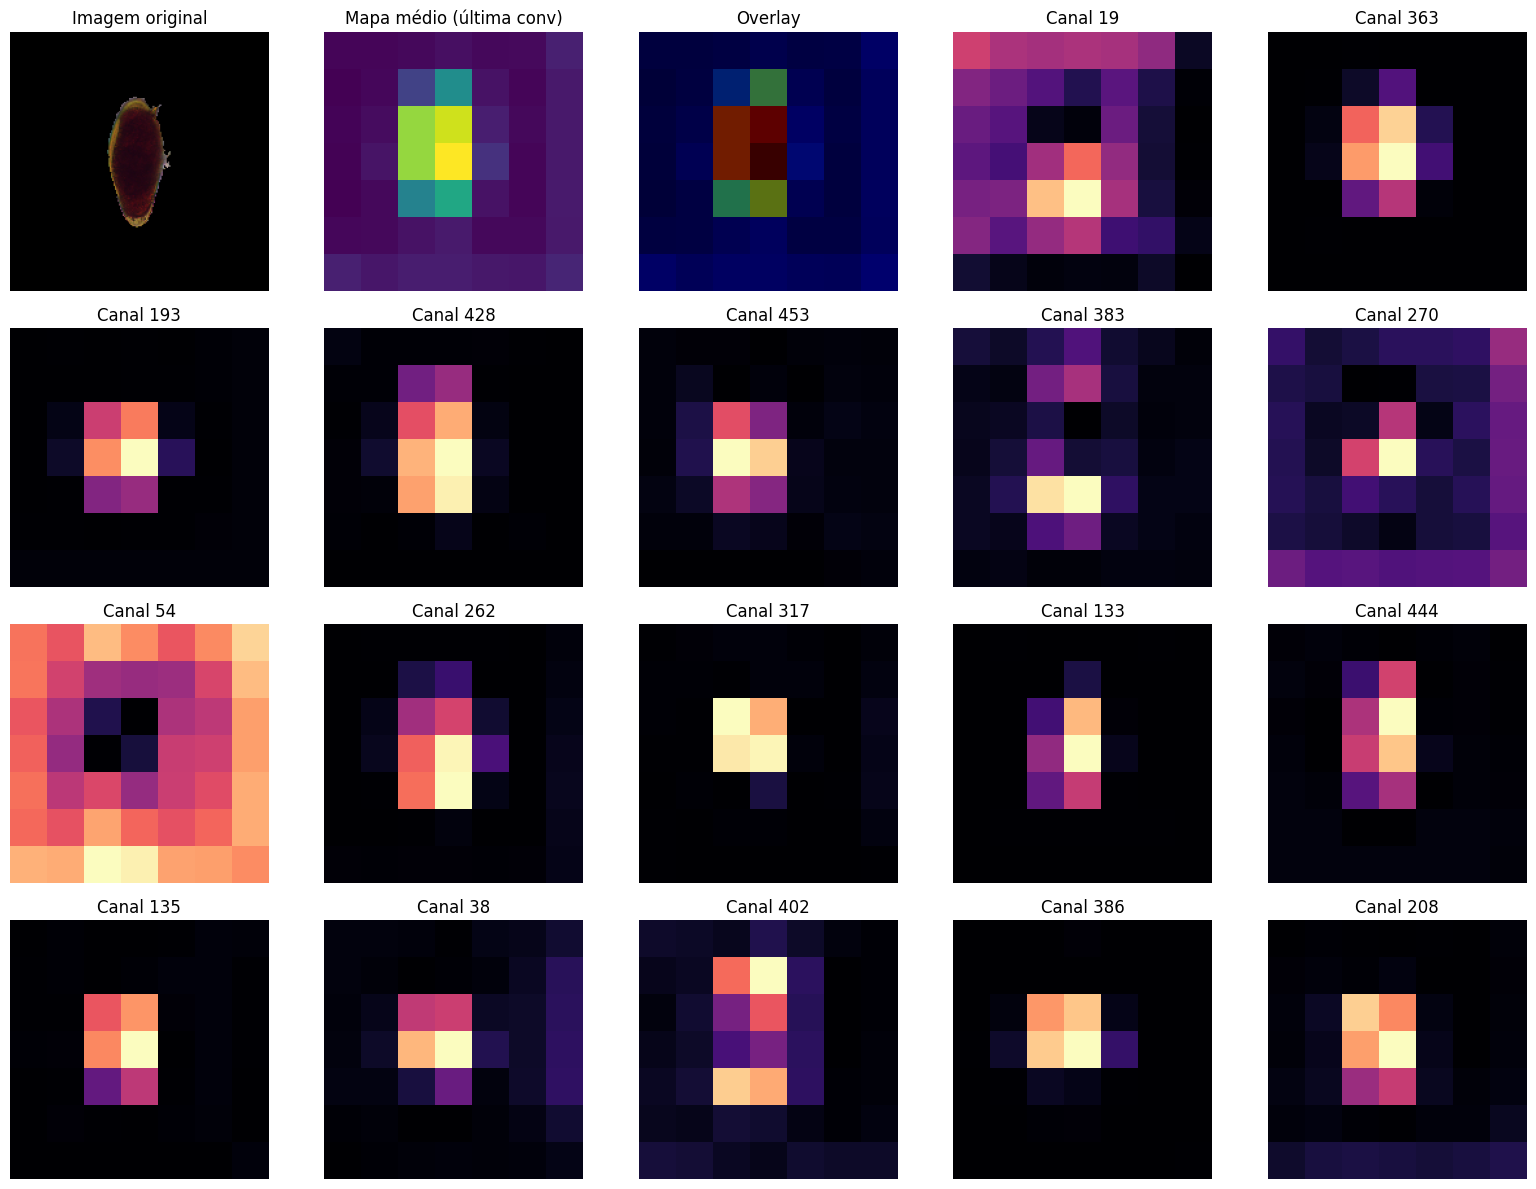

In [ ]:
# Visualizar mapa de ativação após a última camada convolucional (antes da FC)

def _find_first_dataloader(obj):
    if isinstance(obj, dict):
        for v in obj.values():
            dl = _find_first_dataloader(v)
            if dl is not None:
                return dl
    elif hasattr(obj, "dataset") and hasattr(obj, "__iter__"):
        return obj
    return None

loader = _find_first_dataloader(dataloaders)
if loader is None:
    raise ValueError("Nenhum DataLoader encontrado em 'dataloaders'.")

images, labels = next(iter(loader))
# quero escolher a classe da imagem
chosen_class = 6  # Altere para a classe desejada (0 a num_classes-1)
# pegar a primeira imagem da classe escolhida
images = images[labels == chosen_class]
x = images[0:1].to(config["device"])  # 1 imagem

model_scratch = model_scratch.to(config["device"]).eval()

with torch.no_grad():
    feat = model_scratch.features(x)  # saída da última parte convolucional
    pooled = model_scratch.avgpool(feat)
    logits = model_scratch.classifier(torch.flatten(pooled, 1))

print(f"Input shape: {x.shape}")
print(f"Feature map shape (última conv): {feat.shape}")
print(f"Logits shape: {logits.shape}")

# --- Preparar imagem original (desnormalizar para plot) ---
img_np = images[0].permute(1, 2, 0).cpu().numpy()
mean = np.array([0.485, 0.456, 0.406])
std = np.array([0.229, 0.224, 0.225])
img_np = np.clip(img_np * std + mean, 0, 1)

feat_cpu = feat[0].detach().cpu()  # [C, H, W]

# Mapa agregado (média nos canais)
mean_map = feat_cpu.mean(dim=0).numpy()
mean_map = (mean_map - mean_map.min()) / (mean_map.max() - mean_map.min() + 1e-8)

# Top-17 canais mais "ativos"
channel_score = feat_cpu.view(feat_cpu.size(0), -1).mean(dim=1)
k = min(17, feat_cpu.size(0))
top_idx = torch.topk(channel_score, k=k).indices

# --- Plot ---
fig = plt.figure(figsize=(16, 12))
plt.suptitle(f"Dataset: {dataset_name}, Classe: {chosen_class}", fontsize=14, fontweight='bold')

ax1 = plt.subplot(5, 4, 1)
ax1.imshow(img_np)
ax1.set_title("Imagem original")
ax1.axis("off")

ax2 = plt.subplot(5, 4, 2)
ax2.imshow(mean_map, cmap="viridis")
ax2.set_title("Mapa médio (última conv)")
ax2.axis("off")

ax3 = plt.subplot(5, 4, 3)
ax3.imshow(img_np)
ax3.imshow(mean_map, cmap="jet", alpha=0.45)
ax3.set_title("Overlay")
ax3.axis("off")

for i, ch in enumerate(top_idx, start=4):
    ax = plt.subplot(5, 4, i)
    fmap = feat_cpu[ch].numpy()
    fmap = (fmap - fmap.min()) / (fmap.max() - fmap.min() + 1e-8)
    ax.imshow(fmap, cmap="magma")
    ax.set_title(f"Canal {int(ch)}")
    ax.axis("off")

plt.tight_layout()
plt.show()

Input shape: torch.Size([1, 3, 200, 200])
Feature map shape (última conv): torch.Size([1, 576, 7, 7])
Logits shape: torch.Size([1, 9])


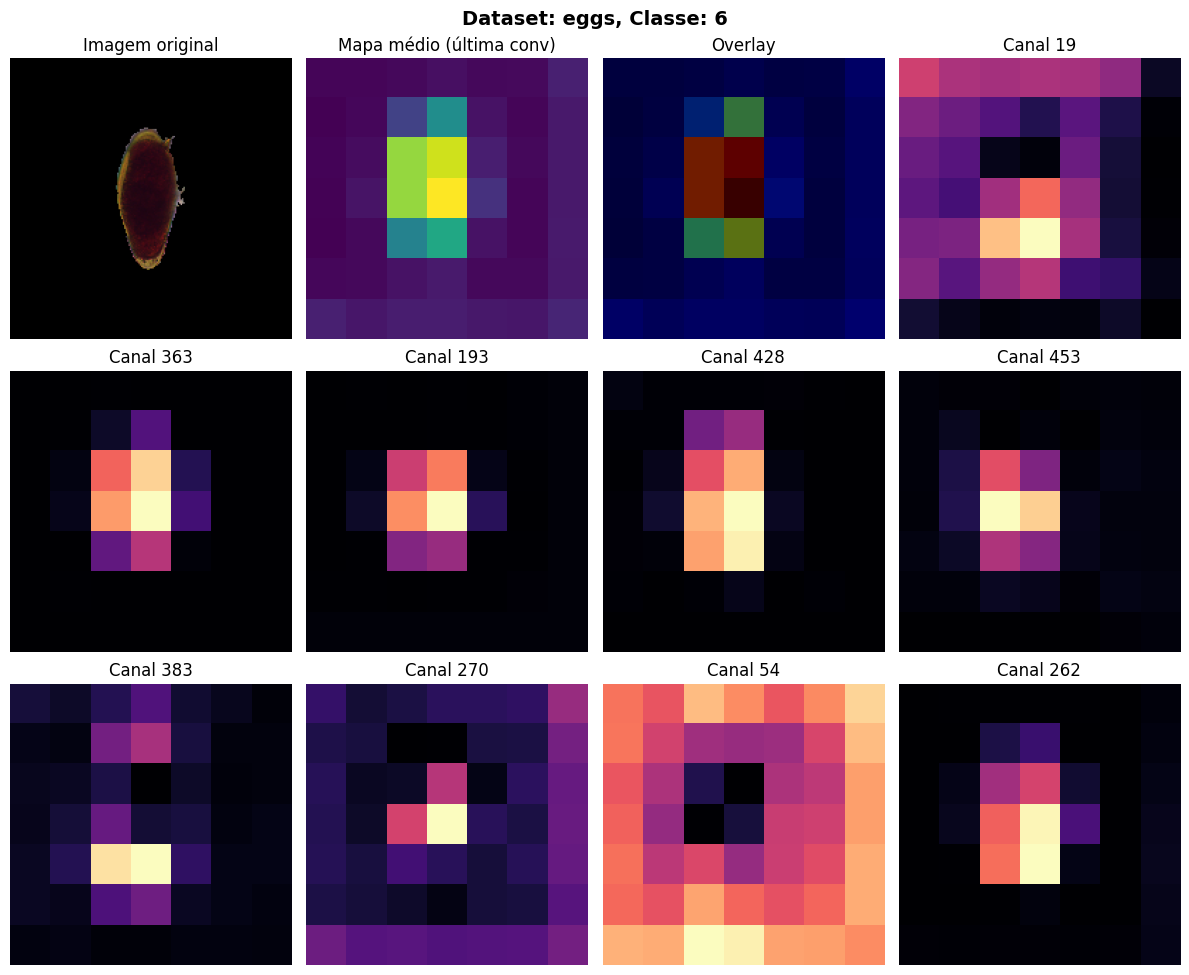

In [3]:
# Visualizar mapa de ativação após a última camada convolucional (antes da FC)

def _find_first_dataloader(obj):
    if isinstance(obj, dict):
        for v in obj.values():
            dl = _find_first_dataloader(v)
            if dl is not None:
                return dl
    elif hasattr(obj, "dataset") and hasattr(obj, "__iter__"):
        return obj
    return None

loader = _find_first_dataloader(dataloaders)
if loader is None:
    raise ValueError("Nenhum DataLoader encontrado em 'dataloaders'.")

images, labels = next(iter(loader))
# quero escolher a classe da imagem
chosen_class = 6  # Altere para a classe desejada (0 a num_classes-1)
# pegar a primeira imagem da classe escolhida
images = images[labels == chosen_class]
x = images[0:1].to(config["device"])  # 1 imagem

model_scratch = model_scratch.to(config["device"]).eval()

with torch.no_grad():
    feat = model_scratch.features(x)  # saída da última parte convolucional
    pooled = model_scratch.avgpool(feat)
    logits = model_scratch.classifier(torch.flatten(pooled, 1))

print(f"Input shape: {x.shape}")
print(f"Feature map shape (última conv): {feat.shape}")
print(f"Logits shape: {logits.shape}")

# --- Preparar imagem original (desnormalizar para plot) ---
img_np = images[0].permute(1, 2, 0).cpu().numpy()
mean = np.array([0.485, 0.456, 0.406])
std = np.array([0.229, 0.224, 0.225])
img_np = np.clip(img_np * std + mean, 0, 1)

feat_cpu = feat[0].detach().cpu()  # [C, H, W]

# Mapa agregado (média nos canais)
mean_map = feat_cpu.mean(dim=0).numpy()
mean_map = (mean_map - mean_map.min()) / (mean_map.max() - mean_map.min() + 1e-8)

# Top-9 canais mais "ativos"
channel_score = feat_cpu.view(feat_cpu.size(0), -1).mean(dim=1)
k = min(9, feat_cpu.size(0))
top_idx = torch.topk(channel_score, k=k).indices

# --- Plot ---
fig = plt.figure(figsize=(12, 10))
plt.suptitle(f"Dataset: {dataset_name}, Classe: {chosen_class}", fontsize=14, fontweight='bold')    
ax1 = plt.subplot(3, 4, 1)
ax1.imshow(img_np)
ax1.set_title("Imagem original")
ax1.axis("off")
ax2 = plt.subplot(3, 4, 2)
ax2.imshow(mean_map, cmap="viridis")
ax2.set_title("Mapa médio (última conv)")
ax2.axis("off")
ax3 = plt.subplot(3, 4, 3)
ax3.imshow(img_np)
ax3.imshow(mean_map, cmap="jet", alpha=0.45)
ax3.set_title("Overlay")
ax3.axis("off")
for i, ch in enumerate(top_idx, start=4):
    ax = plt.subplot(3, 4, i)
    fmap = feat_cpu[ch].numpy()
    fmap = (fmap - fmap.min()) / (fmap.max() - fmap.min() + 1e-8)
    ax.imshow(fmap, cmap="magma")
    ax.set_title(f"Canal {int(ch)}")
    ax.axis("off")
plt.tight_layout()
plt.show()


Input shape: torch.Size([1, 3, 200, 200])
Feature map shape (última conv): torch.Size([1, 576, 7, 7])
Logits shape: torch.Size([1, 9])


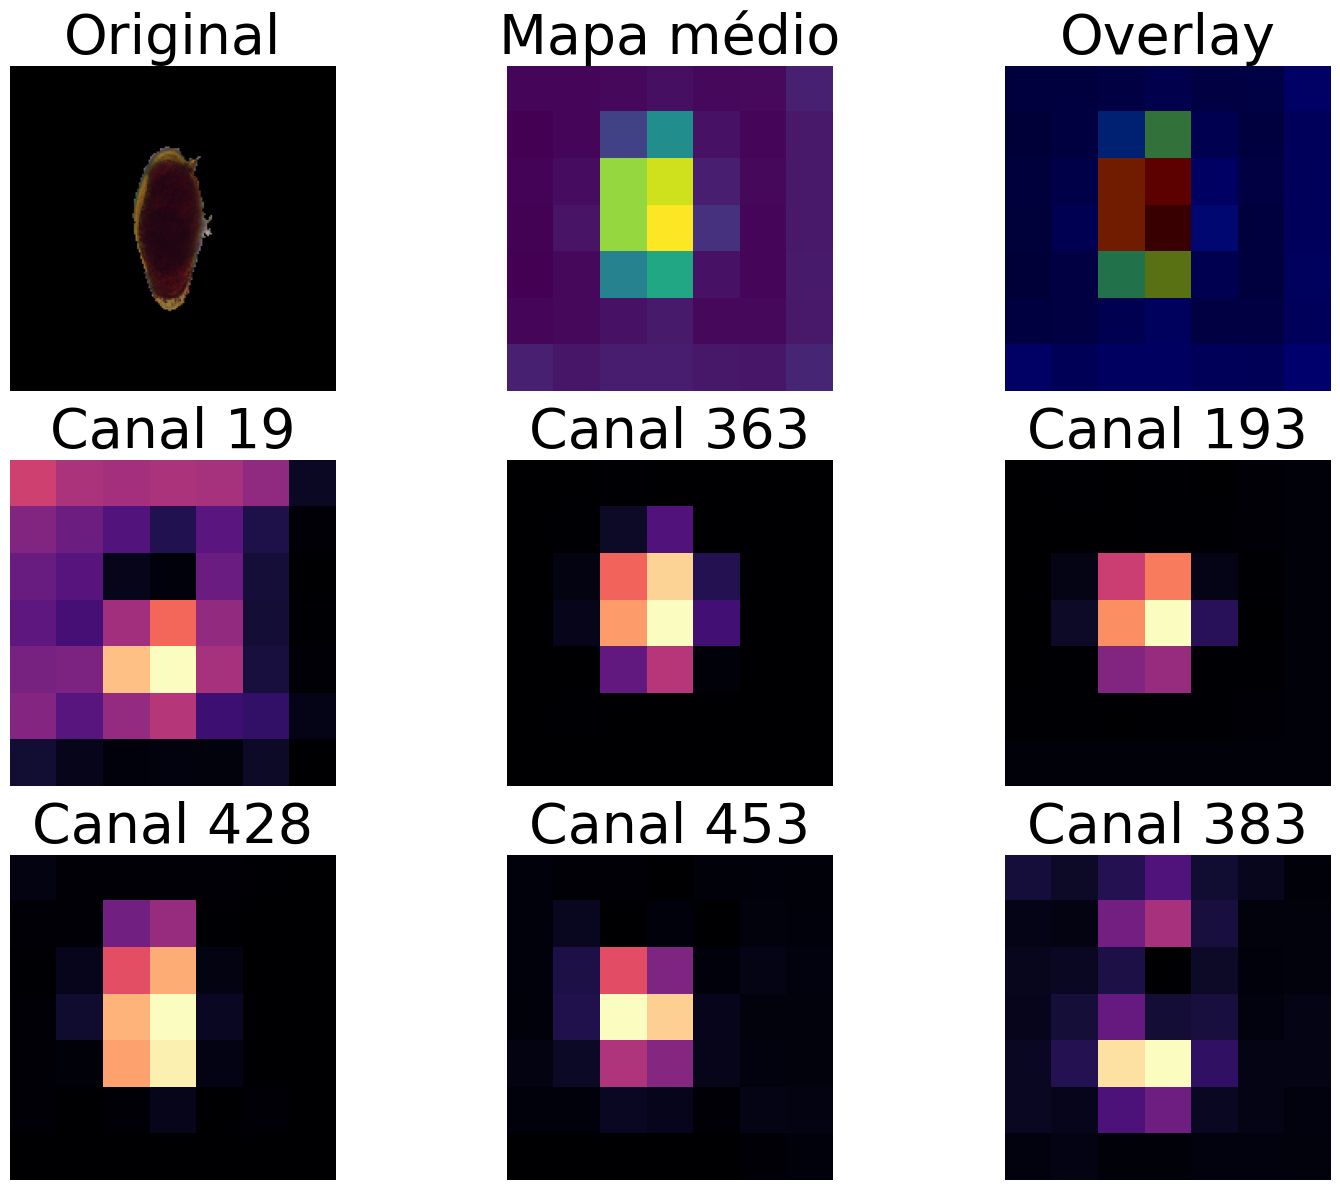

In [7]:
# Visualizar mapa de ativação após a última camada convolucional (antes da FC)

def _find_first_dataloader(obj):
    if isinstance(obj, dict):
        for v in obj.values():
            dl = _find_first_dataloader(v)
            if dl is not None:
                return dl
    elif hasattr(obj, "dataset") and hasattr(obj, "__iter__"):
        return obj
    return None

loader = _find_first_dataloader(dataloaders)
if loader is None:
    raise ValueError("Nenhum DataLoader encontrado em 'dataloaders'.")

images, labels = next(iter(loader))
# quero escolher a classe da imagem
chosen_class = 6  # Altere para a classe desejada (0 a num_classes-1)
# pegar a primeira imagem da classe escolhida
images = images[labels == chosen_class]
x = images[0:1].to(config["device"])  # 1 imagem

model_scratch = model_scratch.to(config["device"]).eval()

with torch.no_grad():
    feat = model_scratch.features(x)  # saída da última parte convolucional
    pooled = model_scratch.avgpool(feat)
    logits = model_scratch.classifier(torch.flatten(pooled, 1))

print(f"Input shape: {x.shape}")
print(f"Feature map shape (última conv): {feat.shape}")
print(f"Logits shape: {logits.shape}")

# --- Preparar imagem original (desnormalizar para plot) ---
img_np = images[0].permute(1, 2, 0).cpu().numpy()
mean = np.array([0.485, 0.456, 0.406])
std = np.array([0.229, 0.224, 0.225])
img_np = np.clip(img_np * std + mean, 0, 1)

feat_cpu = feat[0].detach().cpu()  # [C, H, W]

# Mapa agregado (média nos canais)
mean_map = feat_cpu.mean(dim=0).numpy()
mean_map = (mean_map - mean_map.min()) / (mean_map.max() - mean_map.min() + 1e-8)

# Top-6 canais mais "ativos"
channel_score = feat_cpu.view(feat_cpu.size(0), -1).mean(dim=1)
k = min(6, feat_cpu.size(0))
top_idx = torch.topk(channel_score, k=k).indices
qtd=40
# --- Plot ---
fig = plt.figure(figsize=(16, 12))
# plt.suptitle(f"Dataset: {dataset_name}, Classe: {chosen_class}", fontsize=14, fontweight='bold')    
ax1 = plt.subplot(3, 3, 1)
ax1.imshow(img_np)
ax1.set_title("Original", fontsize=qtd)
ax1.axis("off")
ax2 = plt.subplot(3, 3, 2)
ax2.imshow(mean_map, cmap="viridis")
ax2.set_title("Mapa médio", fontsize=qtd)
ax2.axis("off")
ax3 = plt.subplot(3, 3, 3)
ax3.imshow(img_np)
ax3.imshow(mean_map, cmap="jet", alpha=0.45)
ax3.set_title("Overlay", fontsize=qtd)
ax3.axis("off")
for i, ch in enumerate(top_idx, start=4):
    ax = plt.subplot(3, 3, i)
    fmap = feat_cpu[ch].numpy()
    fmap = (fmap - fmap.min()) / (fmap.max() - fmap.min() + 1e-8)
    ax.imshow(fmap, cmap="magma")
    ax.set_title(f"Canal {int(ch)}", fontsize=qtd)
    ax.axis("off")
plt.tight_layout()
plt.show()


### Larvae: Pre-trained on ImageNet

In [8]:
# Configuration for Larvae Dataset
CONFIG_LARVAE = {
    'dataset_name': 'larvae',
    'split': [1,2,3],
    'percentage': [1, 5, 25, 50, 75, 100],
    'num_classes': 2,
    'batch_size': 16,
    'num_workers': 4,
    'image_size': 200,
    'lr': 1e-4,
    'num_epochs': 100,
    'device': 'cuda' if torch.cuda.is_available() else 'cpu'
}

# Create dataloaders
dataset_name = CONFIG_LARVAE['dataset_name']
model_name = 'mobilenetv3_small_pretrained'
type_model = 'mobilenetv3_small'
pre_trained = True
path = f"{type_model}/{model_name}/{dataset_name}"
config = CONFIG_LARVAE
dataloaders = {}

transforms_larvae = transforms.Compose([
    transforms.Resize((config['image_size'], config['image_size'])),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

dataloaders = utils.create_dataloaders(config=config, transforms=transforms_larvae)

model_scratch, _, _, _ = models.create_model(type_model=type_model, description_path=f"{path}/{model_name}_model_params_{dataset_name}.txt", config=config, pre_trained=pre_trained)

n_flops, n_params = utils.count_flops(model_scratch, input_size=(1, 3, config['image_size'], config['image_size']))
print(f"Model: {model_name} - Dataset: {dataset_name}")
print(f"FLOPs: {n_flops} FLOPs")
print(f"Parameters: {n_params} ")

Model: mobilenetv3_small_pretrained - Dataset: larvae
FLOPs: 54154088.0 FLOPs
Parameters: 1519906.0 


Input shape: torch.Size([1, 3, 200, 200])
Feature map shape (última conv): torch.Size([1, 576, 7, 7])
Logits shape: torch.Size([1, 2])


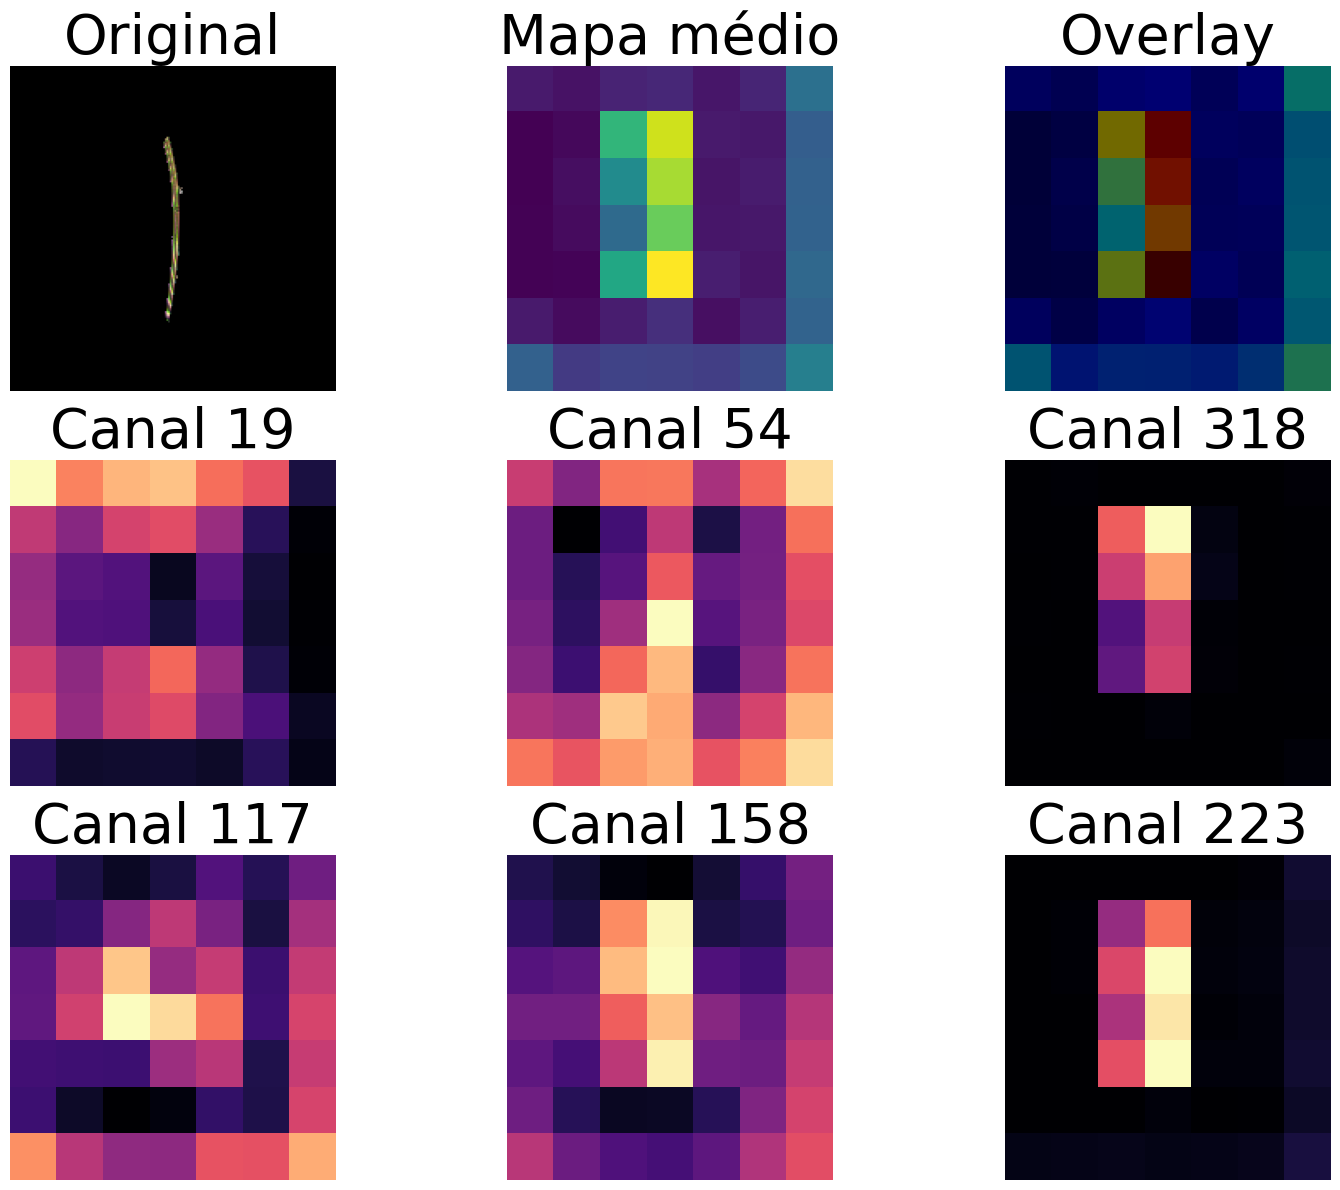

In [9]:
# Visualizar mapa de ativação após a última camada convolucional (antes da FC)

def _find_first_dataloader(obj):
    if isinstance(obj, dict):
        for v in obj.values():
            dl = _find_first_dataloader(v)
            if dl is not None:
                return dl
    elif hasattr(obj, "dataset") and hasattr(obj, "__iter__"):
        return obj
    return None

loader = _find_first_dataloader(dataloaders)
if loader is None:
    raise ValueError("Nenhum DataLoader encontrado em 'dataloaders'.")

images, labels = next(iter(loader))
# quero escolher a classe da imagem
chosen_class = 1  # Altere para a classe desejada (0 a num_classes-1)
# pegar a primeira imagem da classe escolhida
images = images[labels == chosen_class]
x = images[0:1].to(config["device"])  # 1 imagem

model_scratch = model_scratch.to(config["device"]).eval()

with torch.no_grad():
    feat = model_scratch.features(x)  # saída da última parte convolucional
    pooled = model_scratch.avgpool(feat)
    logits = model_scratch.classifier(torch.flatten(pooled, 1))

print(f"Input shape: {x.shape}")
print(f"Feature map shape (última conv): {feat.shape}")
print(f"Logits shape: {logits.shape}")

# --- Preparar imagem original (desnormalizar para plot) ---
img_np = images[0].permute(1, 2, 0).cpu().numpy()
mean = np.array([0.485, 0.456, 0.406])
std = np.array([0.229, 0.224, 0.225])
img_np = np.clip(img_np * std + mean, 0, 1)

feat_cpu = feat[0].detach().cpu()  # [C, H, W]

# Mapa agregado (média nos canais)
mean_map = feat_cpu.mean(dim=0).numpy()
mean_map = (mean_map - mean_map.min()) / (mean_map.max() - mean_map.min() + 1e-8)

# Top-6 canais mais "ativos"
channel_score = feat_cpu.view(feat_cpu.size(0), -1).mean(dim=1)
k = min(6, feat_cpu.size(0))
top_idx = torch.topk(channel_score, k=k).indices
qtd=40
# --- Plot ---
fig = plt.figure(figsize=(16, 12))
# plt.suptitle(f"Dataset: {dataset_name}, Classe: {chosen_class}", fontsize=14, fontweight='bold')    
ax1 = plt.subplot(3, 3, 1)
ax1.imshow(img_np)
ax1.set_title("Original", fontsize=qtd)
ax1.axis("off")
ax2 = plt.subplot(3, 3, 2)
ax2.imshow(mean_map, cmap="viridis")
ax2.set_title("Mapa médio", fontsize=qtd)
ax2.axis("off")
ax3 = plt.subplot(3, 3, 3)
ax3.imshow(img_np)
ax3.imshow(mean_map, cmap="jet", alpha=0.45)
ax3.set_title("Overlay", fontsize=qtd)
ax3.axis("off")
for i, ch in enumerate(top_idx, start=4):
    ax = plt.subplot(3, 3, i)
    fmap = feat_cpu[ch].numpy()
    fmap = (fmap - fmap.min()) / (fmap.max() - fmap.min() + 1e-8)
    ax.imshow(fmap, cmap="magma")
    ax.set_title(f"Canal {int(ch)}", fontsize=qtd)
    ax.axis("off")
plt.tight_layout()
plt.show()


Input shape: torch.Size([1, 3, 200, 200])
Feature map shape (última conv): torch.Size([1, 576, 7, 7])
Logits shape: torch.Size([1, 2])


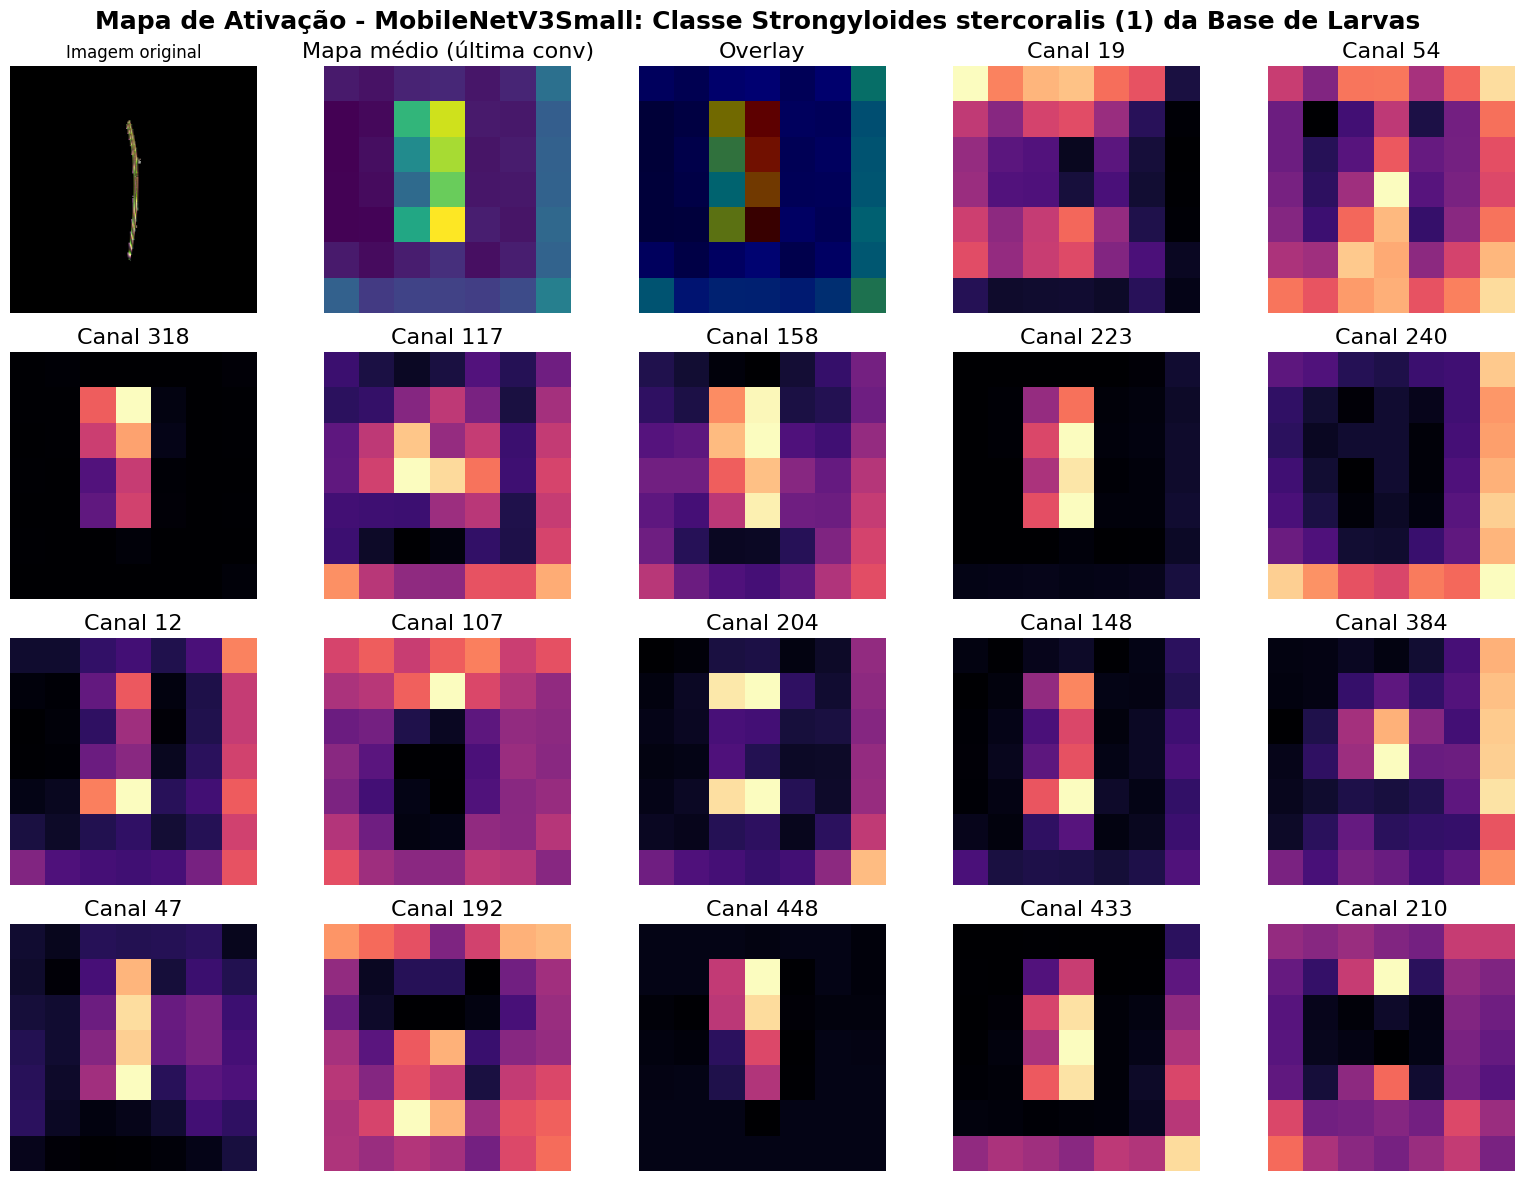

In [29]:
# Visualizar mapa de ativação após a última camada convolucional (antes da FC)

def _find_first_dataloader(obj):
    if isinstance(obj, dict):
        for v in obj.values():
            dl = _find_first_dataloader(v)
            if dl is not None:
                return dl
    elif hasattr(obj, "dataset") and hasattr(obj, "__iter__"):
        return obj
    return None

loader = _find_first_dataloader(dataloaders)
if loader is None:
    raise ValueError("Nenhum DataLoader encontrado em 'dataloaders'.")

images, labels = next(iter(loader))
# quero escolher a classe da imagem
chosen_class = 1 # Altere para a classe desejada (0 a num_classes-1)
# pegar a primeira imagem da classe escolhida
images = images[labels == chosen_class]
x = images[0:1].to(config["device"])  # 1 imagem

model_scratch = model_scratch.to(config["device"]).eval()

with torch.no_grad():
    feat = model_scratch.features(x)  # saída da última parte convolucional
    pooled = model_scratch.avgpool(feat)
    logits = model_scratch.classifier(torch.flatten(pooled, 1))

print(f"Input shape: {x.shape}")
print(f"Feature map shape (última conv): {feat.shape}")
print(f"Logits shape: {logits.shape}")

# --- Preparar imagem original (desnormalizar para plot) ---
img_np = images[0].permute(1, 2, 0).cpu().numpy()
mean = np.array([0.485, 0.456, 0.406])
std = np.array([0.229, 0.224, 0.225])
img_np = np.clip(img_np * std + mean, 0, 1)

feat_cpu = feat[0].detach().cpu()  # [C, H, W]

# Mapa agregado (média nos canais)
mean_map = feat_cpu.mean(dim=0).numpy()
mean_map = (mean_map - mean_map.min()) / (mean_map.max() - mean_map.min() + 1e-8)

# Top-16 canais mais "ativos"
channel_score = feat_cpu.view(feat_cpu.size(0), -1).mean(dim=1)
k = min(17, feat_cpu.size(0))
top_idx = torch.topk(channel_score, k=k).indices

# --- Plot ---
fig = plt.figure(figsize=(16, 12))
plt.suptitle(f"Mapa de Ativação - MobileNetV3Small: Classe Strongyloides stercoralis ({chosen_class}) da Base de Larvas ", fontsize=18, fontweight='bold')

ax1 = plt.subplot(4, 5, 1)
ax1.imshow(img_np)
ax1.set_title("Imagem original")
ax1.axis("off")

ax2 = plt.subplot(4, 5, 2)
ax2.imshow(mean_map, cmap="viridis")
ax2.set_title("Mapa médio (última conv)", fontsize=16)
ax2.axis("off")

ax3 = plt.subplot(4, 5, 3)
ax3.imshow(img_np)
ax3.imshow(mean_map, cmap="jet", alpha=0.45)
ax3.set_title("Overlay", fontsize=16)
ax3.axis("off")

for i, ch in enumerate(top_idx, start=4):
    ax = plt.subplot(4, 5, i)
    fmap = feat_cpu[ch].numpy()
    fmap = (fmap - fmap.min()) / (fmap.max() - fmap.min() + 1e-8)
    ax.imshow(fmap, cmap="magma")
    ax.set_title(f"Canal {int(ch)}", fontsize=16)
    ax.axis("off")

plt.tight_layout()
plt.show()

In [15]:
# Training loop with pre-trained weights
historic_train = trainer.train_loop(config, dataloaders, path, dataset_name, model_name=model_name, type_model=type_model, pre_trained=pre_trained)

# Save training history
with open(f'{path}/{model_name}_historic_{config["dataset_name"]}.json', 'w') as f:
    json.dump(historic_train, f)
    

Early stopping at epoch 45 for split 1 and percentage 1%


Early stopping at epoch 71 for split 2 and percentage 1%


Early stopping at epoch 29 for split 1 and percentage 5%


Early stopping at epoch 22 for split 2 and percentage 5%


Early stopping at epoch 81 for split 3 and percentage 5%


...

Early stopping at epoch 39 for split 2 and percentage 75%


Early stopping at epoch 29 for split 3 and percentage 75%


Early stopping at epoch 46 for split 1 and percentage 100%


Early stopping at epoch 33 for split 2 and percentage 100%


Early stopping at epoch 37 for split 3 and percentage 100%


In [16]:
utils.loss_and_accuracy_split(config, path, model_name, show_plot=False)
utils.loss_and_accuracy_aggregate(config, path, model_name, show_plot=False)

results_test = utils.evaluate_test_set(config, path, model_name, dataloaders, type_model=type_model, pre_trained=pre_trained)  

# Save results to JSON
with open(f'{path}/{model_name}_test_results_{config["dataset_name"]}.json', 'w') as f:
    json.dump(results_test, f)

utils.calculate_and_save_reports(config, path, model_name)

Aggregated classification reports saved to mobilenetv3_small/mobilenetv3_small_pretrained/larvae/mobilenetv3_small_pretrained_aggregated_classification_report_larvae.txt


### Cysts: Pre-trained on ImageNet

In [10]:
# Configuration for Cisto Dataset
CONFIG_CISTO = {
    'dataset_name': 'cistos',
    'split': [1, 2, 3],
    'percentage': [1, 5, 25, 50, 75, 100],
    'num_classes': 7,
    'batch_size': 16,
    'num_workers': 4,
    'image_size': 200,
    'lr': 1e-4,
    'num_epochs': 100,
    'device': 'cuda' if torch.cuda.is_available() else 'cpu'
}

# Create dataloaders
dataset_name = CONFIG_CISTO['dataset_name']
model_name = 'mobilenetv3_small_pretrained'
type_model = 'mobilenetv3_small'
pre_trained = True
path = f"{type_model}/{model_name}/{dataset_name}"
config = CONFIG_CISTO
dataloaders = {}

transforms_cistos = transforms.Compose([
    transforms.Resize((config['image_size'], config['image_size'])),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

dataloaders = utils.create_dataloaders(config=config, transforms=transforms_cistos)

model_scratch, _, _, _ = models.create_model(type_model=type_model, description_path=f"{path}/{model_name}_model_params_{dataset_name}.txt", config=config, pre_trained=pre_trained)

n_flops, n_params = utils.count_flops(model_scratch, input_size=(1, 3, config['image_size'], config['image_size']))
print(f"Model: {model_name} - Dataset: {dataset_name}")
print(f"FLOPs: {n_flops} FLOPs")
print(f"Parameters: {n_params} ")

Model: mobilenetv3_small_pretrained - Dataset: cistos
FLOPs: 54159208.0 FLOPs
Parameters: 1525031.0 


Input shape: torch.Size([1, 3, 200, 200])
Feature map shape (última conv): torch.Size([1, 576, 7, 7])
Logits shape: torch.Size([1, 7])


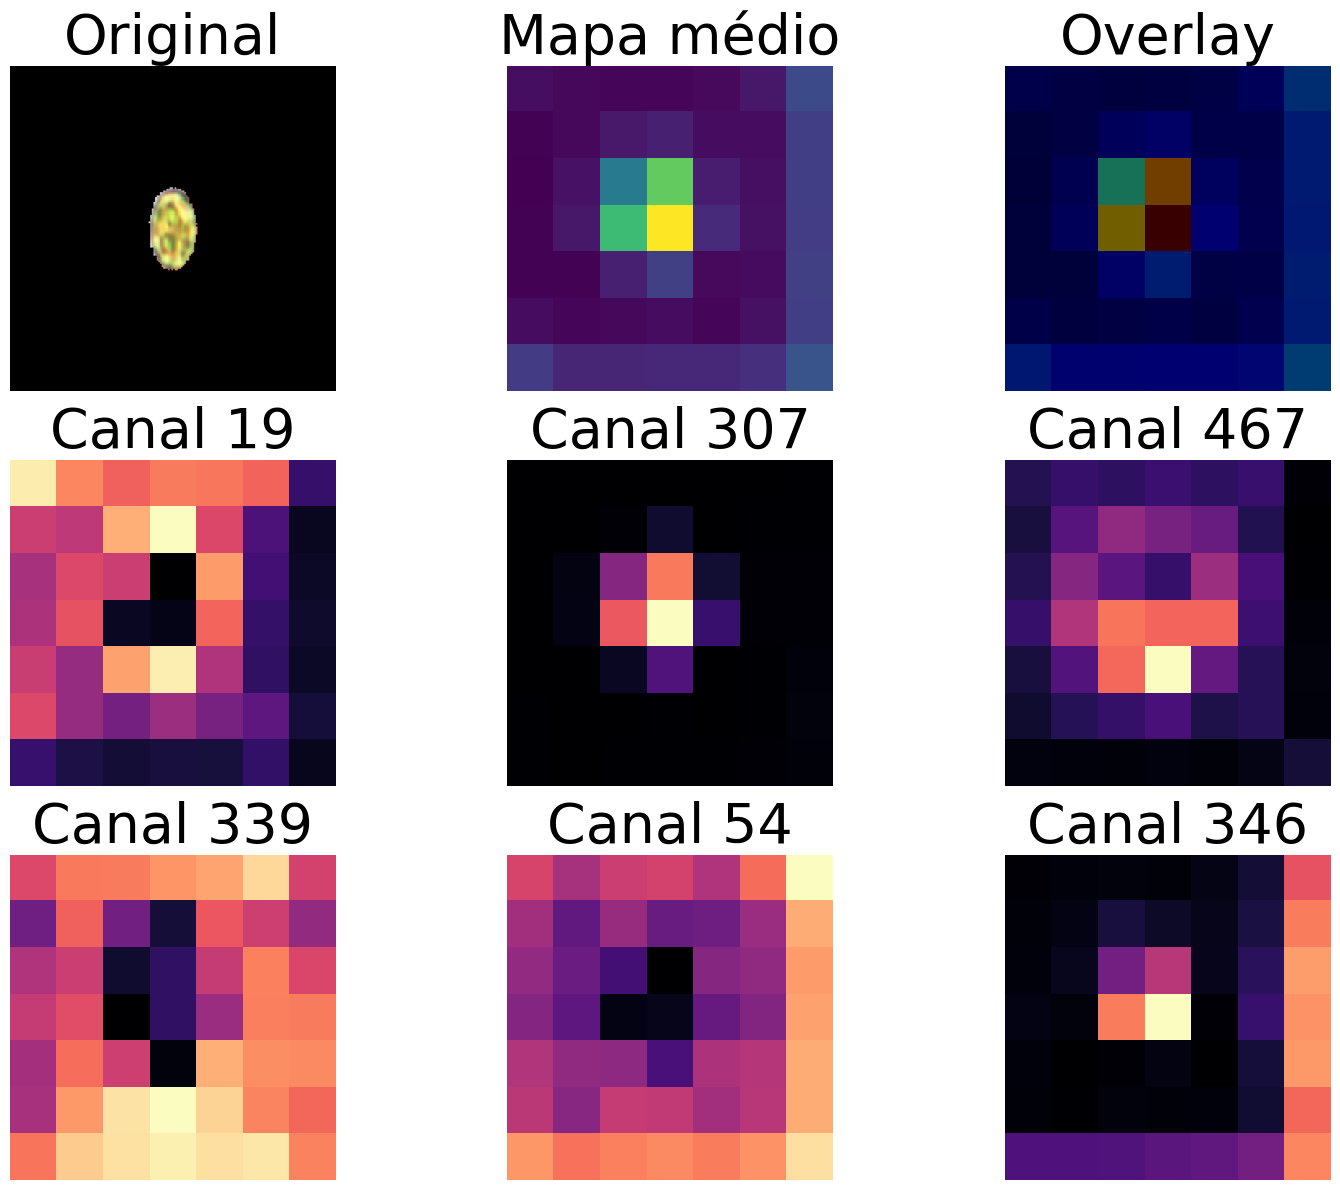

In [12]:
# Visualizar mapa de ativação após a última camada convolucional (antes da FC)

def _find_first_dataloader(obj):
    if isinstance(obj, dict):
        for v in obj.values():
            dl = _find_first_dataloader(v)
            if dl is not None:
                return dl
    elif hasattr(obj, "dataset") and hasattr(obj, "__iter__"):
        return obj
    return None

loader = _find_first_dataloader(dataloaders)
if loader is None:
    raise ValueError("Nenhum DataLoader encontrado em 'dataloaders'.")

images, labels = next(iter(loader))
# quero escolher a classe da imagem
chosen_class = 1  # Altere para a classe desejada (0 a num_classes-1)
# pegar a primeira imagem da classe escolhida
images = images[labels == chosen_class]
x = images[0:1].to(config["device"])  # 1 imagem

model_scratch = model_scratch.to(config["device"]).eval()

with torch.no_grad():
    feat = model_scratch.features(x)  # saída da última parte convolucional
    pooled = model_scratch.avgpool(feat)
    logits = model_scratch.classifier(torch.flatten(pooled, 1))

print(f"Input shape: {x.shape}")
print(f"Feature map shape (última conv): {feat.shape}")
print(f"Logits shape: {logits.shape}")

# --- Preparar imagem original (desnormalizar para plot) ---
img_np = images[0].permute(1, 2, 0).cpu().numpy()
mean = np.array([0.485, 0.456, 0.406])
std = np.array([0.229, 0.224, 0.225])
img_np = np.clip(img_np * std + mean, 0, 1)

feat_cpu = feat[0].detach().cpu()  # [C, H, W]

# Mapa agregado (média nos canais)
mean_map = feat_cpu.mean(dim=0).numpy()
mean_map = (mean_map - mean_map.min()) / (mean_map.max() - mean_map.min() + 1e-8)

# Top-6 canais mais "ativos"
channel_score = feat_cpu.view(feat_cpu.size(0), -1).mean(dim=1)
k = min(6, feat_cpu.size(0))
top_idx = torch.topk(channel_score, k=k).indices
qtd=40
# --- Plot ---
fig = plt.figure(figsize=(16, 12))
# plt.suptitle(f"Dataset: {dataset_name}, Classe: {chosen_class}", fontsize=14, fontweight='bold')    
ax1 = plt.subplot(3, 3, 1)
ax1.imshow(img_np)
ax1.set_title("Original", fontsize=qtd)
ax1.axis("off")
ax2 = plt.subplot(3, 3, 2)
ax2.imshow(mean_map, cmap="viridis")
ax2.set_title("Mapa médio", fontsize=qtd)
ax2.axis("off")
ax3 = plt.subplot(3, 3, 3)
ax3.imshow(img_np)
ax3.imshow(mean_map, cmap="jet", alpha=0.45)
ax3.set_title("Overlay", fontsize=qtd)
ax3.axis("off")
for i, ch in enumerate(top_idx, start=4):
    ax = plt.subplot(3, 3, i)
    fmap = feat_cpu[ch].numpy()
    fmap = (fmap - fmap.min()) / (fmap.max() - fmap.min() + 1e-8)
    ax.imshow(fmap, cmap="magma")
    ax.set_title(f"Canal {int(ch)}", fontsize=qtd)
    ax.axis("off")
plt.tight_layout()
plt.show()


Input shape: torch.Size([1, 3, 200, 200])
Feature map shape (última conv): torch.Size([1, 576, 7, 7])
Logits shape: torch.Size([1, 7])


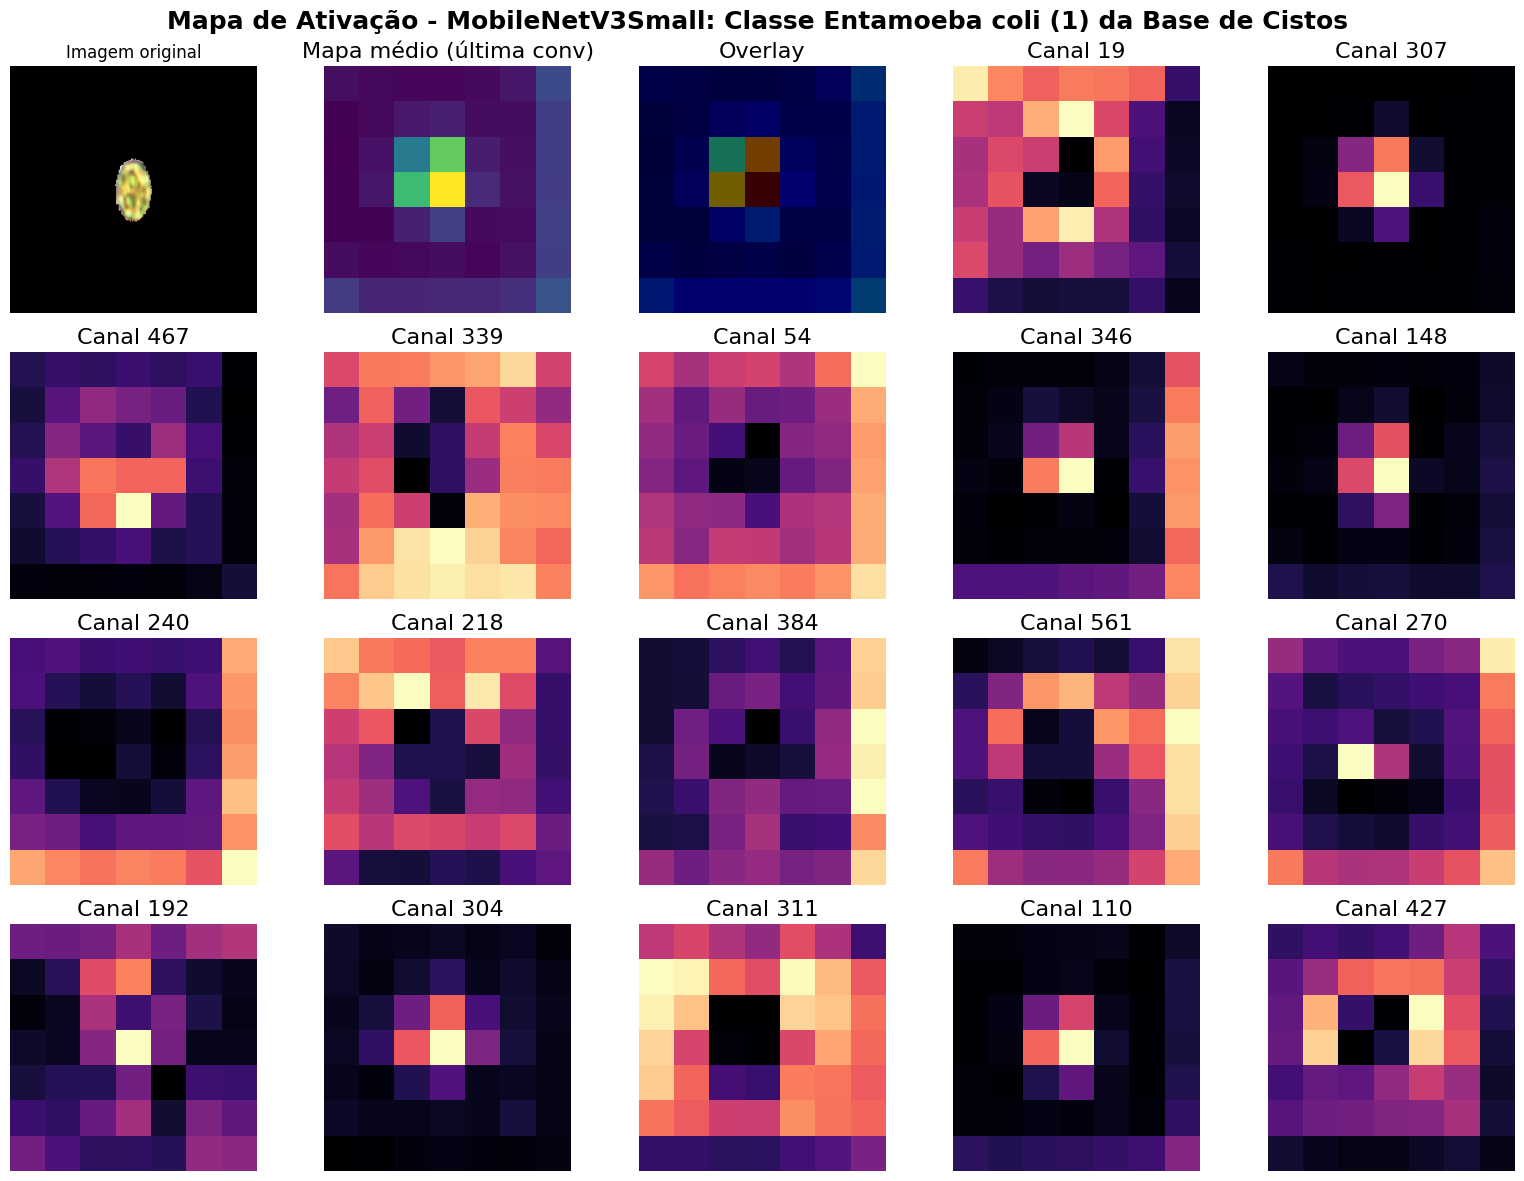

In [11]:
# Visualizar mapa de ativação após a última camada convolucional (antes da FC)

def _find_first_dataloader(obj):
    if isinstance(obj, dict):
        for v in obj.values():
            dl = _find_first_dataloader(v)
            if dl is not None:
                return dl
    elif hasattr(obj, "dataset") and hasattr(obj, "__iter__"):
        return obj
    return None

loader = _find_first_dataloader(dataloaders)
if loader is None:
    raise ValueError("Nenhum DataLoader encontrado em 'dataloaders'.")

images, labels = next(iter(loader))
# quero escolher a classe da imagem
chosen_class = 1 # Altere para a classe desejada (0 a num_classes-1)
# pegar a primeira imagem da classe escolhida
images = images[labels == chosen_class]
x = images[0:1].to(config["device"])  # 1 imagem

model_scratch = model_scratch.to(config["device"]).eval()

with torch.no_grad():
    feat = model_scratch.features(x)  # saída da última parte convolucional
    pooled = model_scratch.avgpool(feat)
    logits = model_scratch.classifier(torch.flatten(pooled, 1))

print(f"Input shape: {x.shape}")
print(f"Feature map shape (última conv): {feat.shape}")
print(f"Logits shape: {logits.shape}")

# --- Preparar imagem original (desnormalizar para plot) ---
img_np = images[0].permute(1, 2, 0).cpu().numpy()
mean = np.array([0.485, 0.456, 0.406])
std = np.array([0.229, 0.224, 0.225])
img_np = np.clip(img_np * std + mean, 0, 1)

feat_cpu = feat[0].detach().cpu()  # [C, H, W]

# Mapa agregado (média nos canais)
mean_map = feat_cpu.mean(dim=0).numpy()
mean_map = (mean_map - mean_map.min()) / (mean_map.max() - mean_map.min() + 1e-8)

# Top-16 canais mais "ativos"
channel_score = feat_cpu.view(feat_cpu.size(0), -1).mean(dim=1)
k = min(17, feat_cpu.size(0))
top_idx = torch.topk(channel_score, k=k).indices

# --- Plot ---
fig = plt.figure(figsize=(16, 12))
plt.suptitle(f"Mapa de Ativação - MobileNetV3Small: Classe Entamoeba coli ({chosen_class}) da Base de Cistos ", fontsize=18, fontweight='bold')

ax1 = plt.subplot(4, 5, 1)
ax1.imshow(img_np)
ax1.set_title("Imagem original")
ax1.axis("off")

ax2 = plt.subplot(4, 5, 2)
ax2.imshow(mean_map, cmap="viridis")
ax2.set_title("Mapa médio (última conv)", fontsize=16)
ax2.axis("off")

ax3 = plt.subplot(4, 5, 3)
ax3.imshow(img_np)
ax3.imshow(mean_map, cmap="jet", alpha=0.45)
ax3.set_title("Overlay", fontsize=16)
ax3.axis("off")

for i, ch in enumerate(top_idx, start=4):
    ax = plt.subplot(4, 5, i)
    fmap = feat_cpu[ch].numpy()
    fmap = (fmap - fmap.min()) / (fmap.max() - fmap.min() + 1e-8)
    ax.imshow(fmap, cmap="magma")
    ax.set_title(f"Canal {int(ch)}", fontsize=16)
    ax.axis("off")

plt.tight_layout()
plt.show()

In [18]:
# Training loop with pre-trained weights
historic_train = trainer.train_loop(config, dataloaders, path, dataset_name, model_name=model_name, type_model=type_model, pre_trained=pre_trained)

# Save training history
with open(f'{path}/{model_name}_historic_{config["dataset_name"]}.json', 'w') as f:
    json.dump(historic_train, f)
    

Early stopping at epoch 32 for split 1 and percentage 1%


Early stopping at epoch 21 for split 2 and percentage 1%


Early stopping at epoch 31 for split 3 and percentage 1%


Early stopping at epoch 82 for split 1 and percentage 5%


Early stopping at epoch 89 for split 2 and percentage 5%


...

Early stopping at epoch 90 for split 2 and percentage 75%


Early stopping at epoch 34 for split 3 and percentage 75%


Early stopping at epoch 45 for split 1 and percentage 100%


Early stopping at epoch 40 for split 2 and percentage 100%


Early stopping at epoch 57 for split 3 and percentage 100%


In [19]:
utils.loss_and_accuracy_split(config, path, model_name, show_plot=False)
utils.loss_and_accuracy_aggregate(config, path, model_name, show_plot=False)

results_test = utils.evaluate_test_set(config, path, model_name, dataloaders, type_model=type_model, pre_trained=pre_trained)  

# Save results to JSON
with open(f'{path}/{model_name}_test_results_{config["dataset_name"]}.json', 'w') as f:
    json.dump(results_test, f)

utils.calculate_and_save_reports(config, path, model_name)

Aggregated classification reports saved to mobilenetv3_small/mobilenetv3_small_pretrained/cistos/mobilenetv3_small_pretrained_aggregated_classification_report_cistos.txt
